In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set a random seed for reproducibility
np.random.seed(42)

In [2]:
def custom_least_squares(x, y):
    """
    Calculates the slope (m) and intercept (b) for a linear best-fit line
    using the Least Squares Method from scratch.
    """
    n = len(x)
    
    # Calculate the required sums
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xy = np.sum(x * y)
    sum_x_squared = np.sum(x**2)
    
    # Apply the formulas for m and b
    m = (n * sum_xy - sum_x * sum_y) / (n * sum_x_squared - sum_x**2)
    b = (sum_y - m * sum_x) / n
    
    return m, b

In [3]:
# Create random vectors
x_random = np.random.rand(20) * 10
x_random.sort() # Sorting the X vector as requested
y_random = np.random.rand(20) * 10

# 1. Using Custom Method
m_custom_rand, b_custom_rand = custom_least_squares(x_random, y_random)

# 2. Using Built-in Numpy Method
A_random = np.vstack([x_random, np.ones(len(x_random))]).T
m_np_rand, b_np_rand = np.linalg.lstsq(A_random, y_random, rcond=None)[0]

print("--- Random Vectors Test ---")
print(f"Custom Method -> Slope: {m_custom_rand:.4f}, Intercept: {b_custom_rand:.4f}")
print(f"NumPy Method  -> Slope: {m_np_rand:.4f}, Intercept: {b_np_rand:.4f}")

--- Random Vectors Test ---
Custom Method -> Slope: 0.1273, Intercept: 3.9657
NumPy Method  -> Slope: 0.1273, Intercept: 3.9657


In [4]:
# Choose a linear function: y = 3x + 5
m_true = 3.0
b_true = 5.0

# Create X values: 0 to 1, steps of .01
X = np.arange(0, 1.01, 0.01)

# Add random error +/- random_number(0, 1)
# We will use uniform distribution between -1 and 1 to simulate the +/- effect
error = np.random.uniform(-1, 1, len(X))

# Calculate Y
Y = (m_true * X) + b_true + error

In [5]:
# Custom Method
m_custom, b_custom = custom_least_squares(X, Y)

# Numpy Method
A = np.vstack([X, np.ones(len(X))]).T
m_np, b_np = np.linalg.lstsq(A, Y, rcond=None)[0]

print("--- Known Linear Function Test ---")
print(f"Original Equation: y = {m_true}x + {b_true}")
print(f"Custom Method   -> Slope: {m_custom:.4f}, Intercept: {b_custom:.4f}")
print(f"NumPy Method    -> Slope: {m_np:.4f}, Intercept: {b_np:.4f}")

--- Known Linear Function Test ---
Original Equation: y = 3.0x + 5.0
Custom Method   -> Slope: 3.1289, Intercept: 4.9230
NumPy Method    -> Slope: 3.1289, Intercept: 4.9230


In [6]:
# Calculate predicted Y values
Y_predicted = m_custom * X + b_custom

# Calculate absolute residual errors
residuals = np.abs(Y - Y_predicted)

# Find indices of max and min residuals
max_idx = np.argmax(residuals)
min_idx = np.argmin(residuals)

print("--- Residual Errors ---")
print(f"Largest Residual Error: {residuals[max_idx]:.4f}")
print(f"Occurs at Point -> X: {X[max_idx]:.2f}, Y_actual: {Y[max_idx]:.4f}, Y_predicted: {Y_predicted[max_idx]:.4f}\n")

print(f"Smallest Residual Error: {residuals[min_idx]:.4f}")
print(f"Occurs at Point -> X: {X[min_idx]:.2f}, Y_actual: {Y[min_idx]:.4f}, Y_predicted: {Y_predicted[min_idx]:.4f}")

--- Residual Errors ---
Largest Residual Error: 1.0226
Occurs at Point -> X: 0.88, Y_actual: 6.6539, Y_predicted: 7.6765

Smallest Residual Error: 0.0063
Occurs at Point -> X: 0.55, Y_actual: 6.6376, Y_predicted: 6.6439


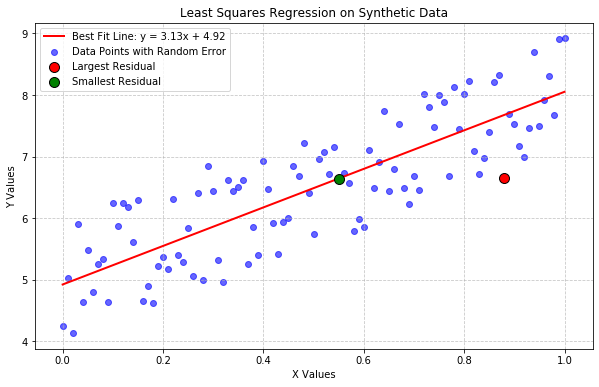

In [7]:
plt.figure(figsize=(10, 6))

# Plot the original data points
plt.scatter(X, Y, color='blue', alpha=0.6, label='Data Points with Random Error')

# Plot the predicted best-fit line
plt.plot(X, Y_predicted, color='red', linewidth=2, label=f'Best Fit Line: y = {m_custom:.2f}x + {b_custom:.2f}')

# Plot formatting
plt.title('Least Squares Regression on Synthetic Data')
plt.xlabel('X Values')
plt.ylabel('Y Values')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Highlight the points with min and max residuals
plt.scatter(X[max_idx], Y[max_idx], color='red', edgecolors='black', s=100, label='Largest Residual', zorder=5)
plt.scatter(X[min_idx], Y[min_idx], color='green', edgecolors='black', s=100, label='Smallest Residual', zorder=5)

# Refresh legend to include highlighted points
plt.legend()

plt.show()